Nuestro objetivo es aplicar algún modelo clásico (estadístico) de forecasting para hacer predicciones futuras de las ventas.

In [2]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.arima.model import ARIMA 
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings


ruta_csv = Path("..") / "data" / "processed" / "Ventas_dia.csv"

# Cargar el CSV en un DataFrame
ventas = pd.read_csv(ruta_csv)
ventas["Fecha"]= pd.to_datetime(ventas["Fecha"])
ventas = ventas.set_index("Fecha")

print(ventas)

              Monto
Fecha              
1996-07-04   566.00
1996-07-05  2329.25
1996-07-08  3106.75
1996-07-09  4662.50
1996-07-10  1806.00
...             ...
1997-02-06   710.50
1997-02-07  1348.70
1997-02-10  9441.01
1997-02-11  2246.00
1997-02-12   673.20

[160 rows x 1 columns]


Cargamos la serie correspondiente a las ventas previamente extraída y limpiada.

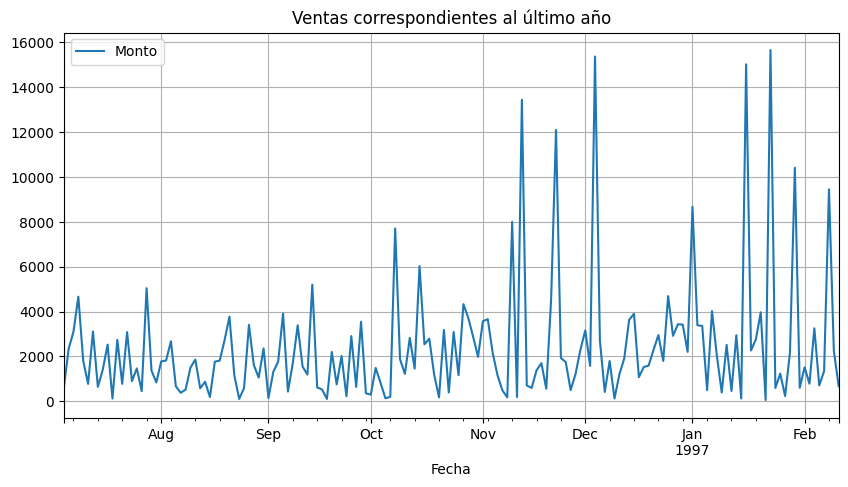

In [3]:
ventas.plot(figsize=(10, 5))
plt.title("Ventas correspondientes al último año")
plt.grid()
plt.show()

Como pudímos ver en el análisis EDA la serie es estacionaria, no hay tendencia y parece que tampoco hay estacionalidad por lo que el mejor modelo debe ser una suavización exponencial simple, aunque antes notemos que da la impreción que la varianza aumenta con el tiempo y por lo que puede que se necesite aplicar alguna función logarítmica.

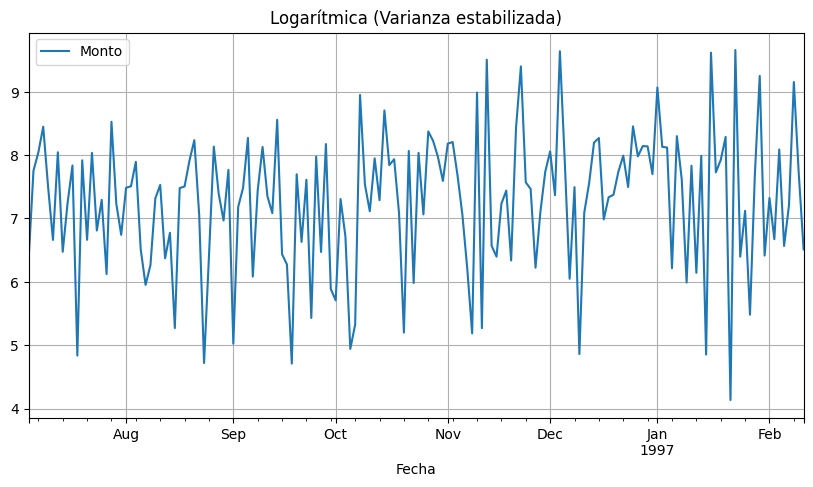

In [4]:
#Función logarítmica

serie_log = np.log(ventas)

serie_log.plot(figsize=(10, 5))
plt.title("Logarítmica (Varianza estabilizada)")
plt.grid()
plt.show()

Veamos que la varianza se estabilizó con el logaritmo y veamos su función de autocorrelación y autocorrelación parcial.

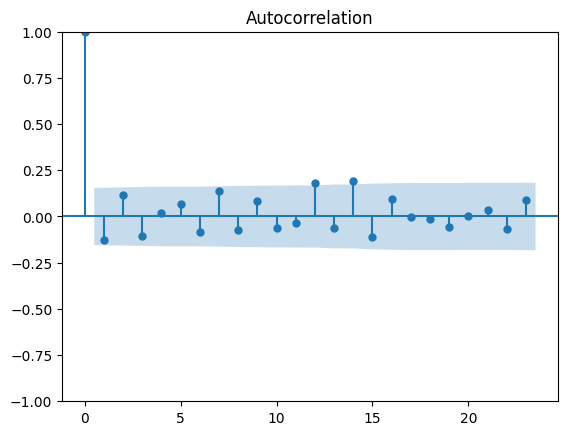

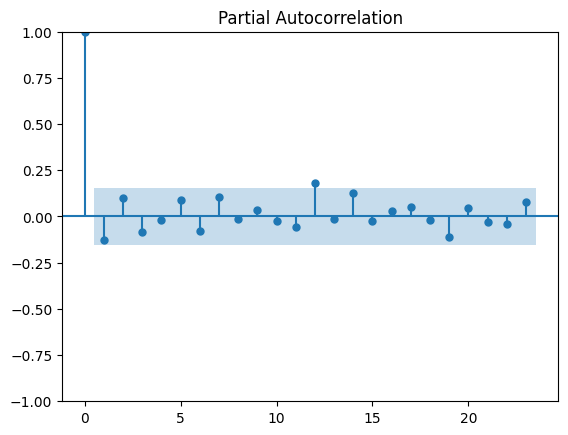

In [5]:
plot_acf(serie_log)
plt.show()

plot_pacf(serie_log)
plt.show()

Reafirmamos el hecho de que no hay estacionalidad y los valores nuevos no estan muy correlacionados con los pasados. La mejor opción sera una suavización exponencial simple.

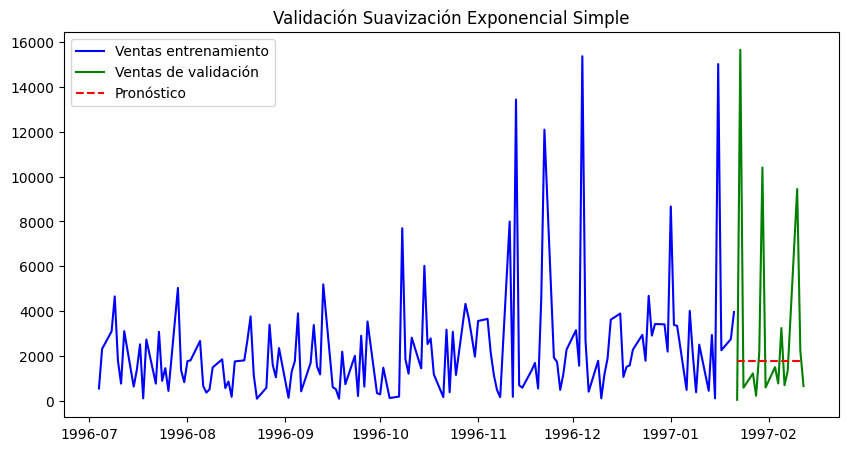

MAE 2658.378228003123
RMSE 4605.377856885253


In [6]:
#Suavización Exponencial Simple

warnings.filterwarnings('ignore')

train_size = int(len(serie_log) * 0.9)
train, test = serie_log[0:train_size], serie_log[train_size:len(serie_log)]

modelo = SimpleExpSmoothing(train, initialization_method="estimated").fit()
pronostico_test_log = modelo.forecast(len(test))
test_pronostico = np.exp(pronostico_test_log)
test_real = np.exp(test)
train_real = np.exp(train)

plt.figure(figsize=(10, 5))
plt.plot(train_real, color='blue', label="Ventas entrenamiento")
plt.plot(test_real, color='green', label="Ventas de validación")
plt.plot(test_pronostico, color='red', label='Pronóstico', linestyle='--')
plt.title("Validación Suavización Exponencial Simple")
plt.legend()
plt.show()


print("MAE", mean_absolute_error(test_pronostico, test_real))
print("RMSE", np.sqrt(mean_squared_error(test_pronostico, test_real)))

En la gráfica podemos ver que el modelo calcula el precio más probable tomando en cuanta las ventas pasadas pero al ver el MAE y el RMSE notemos que el error en general es grande por lo ruidosa que es la serie, intentaremos probar algún otro modelo.

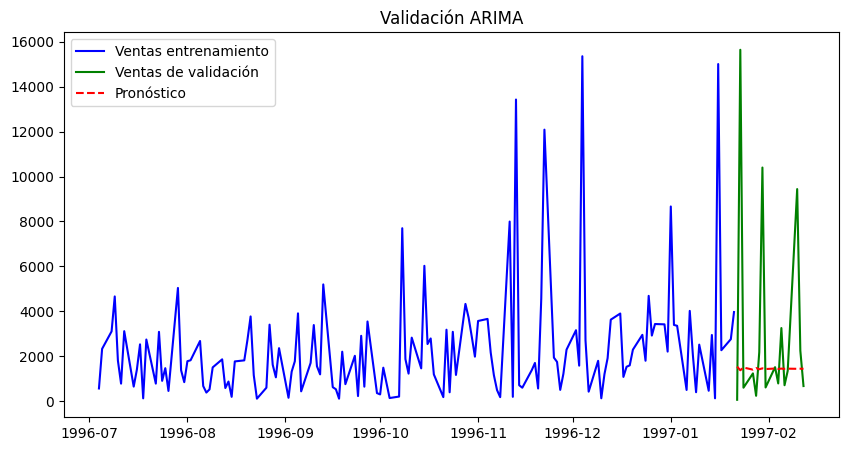

MAE:  2591.9881111097225
RMSE:  4734.513117394136


In [7]:
#ARIMA

warnings.filterwarnings('ignore')

modelo_arima = ARIMA(train, order=(1, 0, 1)).fit()

pronostico_arima_log = modelo_arima.forecast(len(test))
pronostico_arima_real = np.exp(pronostico_arima_log)

plt.figure(figsize=(10, 5))
plt.plot(train_real, color='blue', label="Ventas entrenamiento")
plt.plot(test_real, color='green', label="Ventas de validación")
plt.plot(pronostico_arima_real, color='red', label='Pronóstico', linestyle='--')
plt.title("Validación ARIMA")
plt.legend()
plt.show()

print("MAE: ", mean_absolute_error(pronostico_arima_real, test_real))
print("RMSE: ", np.sqrt(mean_squared_error(pronostico_arima_real, test_real)))





Intentamos usar un modelo ARIMA, cuyos parametros obtuvimos del análisis del acf, pacf, y dicky-fuller, sobre la serie con varianza estable por logaritmo pero veamos que debido a los outliers de ventas muy altas en ciertos días, el MAE y RMSE siguen siendo altos. Podríamos aceptar ese nivel de error pero también podemos usar algún método para tratar los outliers como por ejemplo Winzorización para que lo valores grandes no sean tan extremos y no necesariamente eliminar estos datos atípicos.

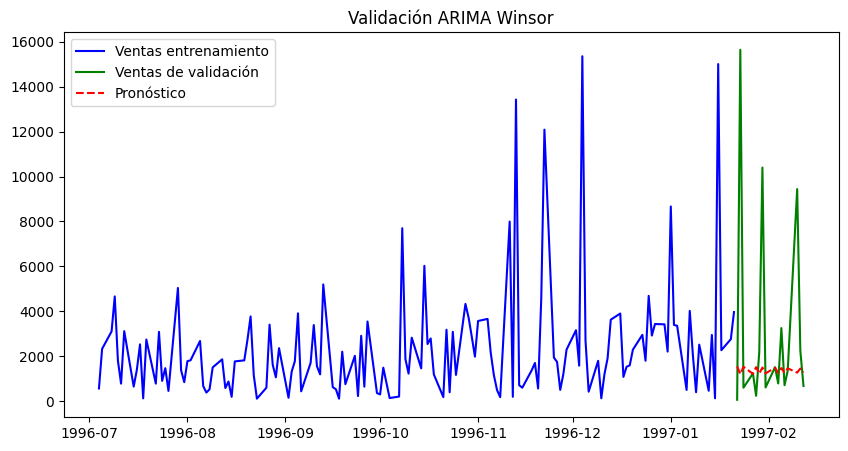

MAE:  2571.8568095488804
RMSE:  1369.2228143337907


In [ ]:
#ARIMA con método Winsor

limite_superior = np.percentile(train, 95) #Usaremos el percentíl 95 para no sobreajustar
train_winsor = train.clip(upper=limite_superior)

modelo_arima_winsor = ARIMA(train_winsor, order=(1, 0, 1)).fit()
pronostico_winsor_log = modelo_arima_winsor.forecast(len(test))
pronostico_winsor_real = np.exp(pronostico_winsor_log)

plt.figure(figsize=(10, 5))
plt.plot(train_real, color='blue', label="Ventas entrenamiento")
plt.plot(test_real, color='green', label="Ventas de validación")
plt.plot(pronostico_winsor_real, color='red', label='Pronóstico', linestyle='--')
plt.title("Validación ARIMA Winsor")
plt.legend()
plt.show()

print("MAE: ", mean_absolute_error(pronostico_winsor_real, test_real))
print("RMSE: ", np.sqrt(mean_squared_error(pronostico_winsor_real, test)))

Después de aplicar un método Winsor sobre los outliers notemos que el RMSE disminuyó considerablemente y en la gráfica podemos ver que en el pronóstico en vez de una línea recta ahora hay ciertas oscilaciones que se ajustan más a la serie pero sin dejarse llevar por todo el ruído de esta.